In [1]:
from pathlib import Path

import numpy as onp
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
BASERESULTSDIR = Path("example_results/")

plt.rcParams["font.size"] = 14
markerlist = ["o", "s", "d", "v", "^"]
# Settings for annotating the data points with the cutoff
# See https://matplotlib.org/stable/users/explain/artists/
ha = "center"
va = "top"
dx, dy = -3 / 72.0, -4 / 72.0

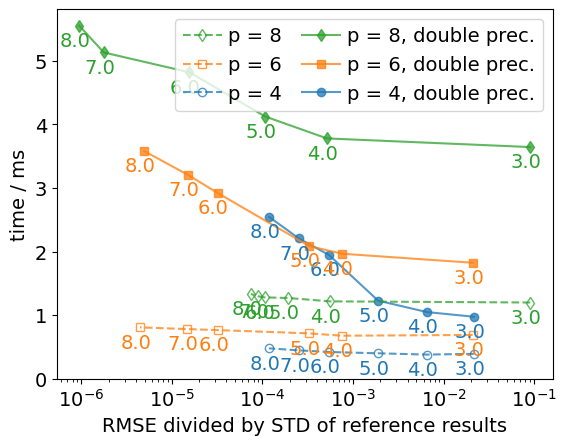

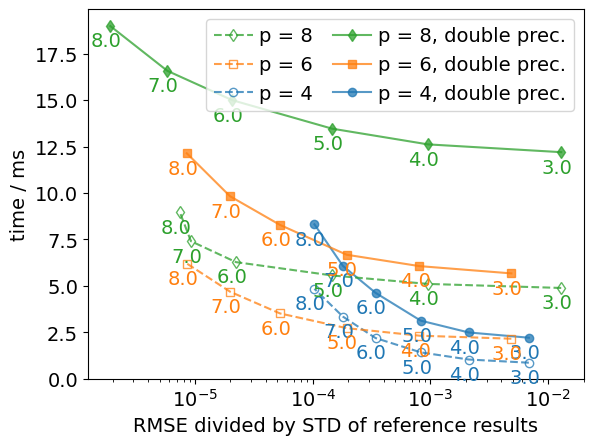

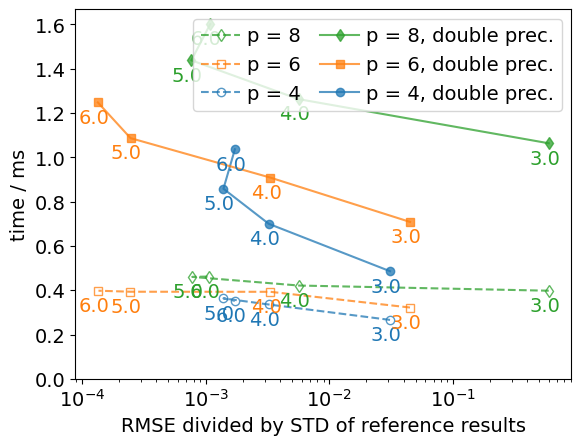

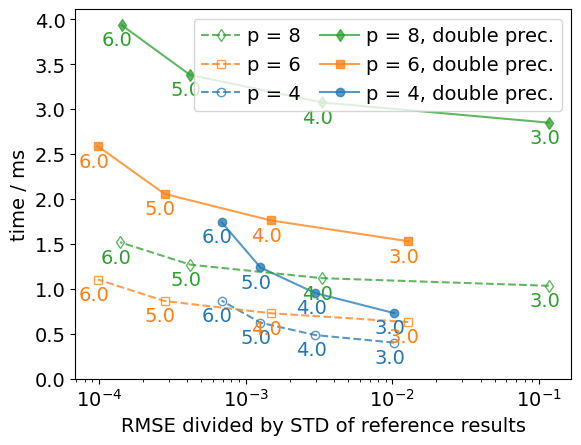

In [3]:
# TODO: include slab structures?
for pbclabel in ["nonperiodic", "periodic"]:
    results = []
    resultsdirname = pbclabel
    df = pd.read_csv(BASERESULTSDIR / resultsdirname / "results.csv")
    df.insert(len(df.columns), "double_precision", [False] * len(df))
    results.append(df)
    resultsdirname += "_doubleprec"
    df = pd.read_csv(BASERESULTSDIR / resultsdirname / "results.csv")
    df.insert(len(df.columns), "double_precision", [True] * len(df))
    results.append(df)
    results = pd.concat(results)

    # TODO: include chargegrad, stress?
    for quantity in ["energy", "forces"]:
        unique_ps = results.loc[results["quantity"] == quantity, "p"].unique()
        unique_ps = onp.sort(unique_ps)
        # fig, ax = plt.subplots(constrained_layout=True)
        fig, ax = plt.subplots()
        ax.set_xlabel("RMSE divided by STD of reference results")
        ax.set_ylabel("time / ms")
        ax.set_xscale("log")
        offset = mpl.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)
        annotations_transform = ax.transData + offset
        lines = []
        for p, marker in zip(unique_ps, markerlist):
            for doubleprec, linestyle, markerfacecolor in zip(
                [False, True], ["--", "-"], ["none", None]
            ):
                selection = results.loc[
                    (
                        (results["p"] == p)
                        & (results["quantity"] == quantity)
                        & (results["double_precision"] == doubleprec)
                    )
                ]
                cutoffs = selection.level_zero_cutoff
                errors = selection.relative_rmse
                times = selection.time * 10**3
                if doubleprec:
                    color = lines[-1].get_color()
                else:
                    color = None
                label = f"p = {p}"
                if doubleprec:
                    label += ", double prec."
                lines += ax.plot(
                    errors,
                    times,
                    alpha=0.75,
                    marker=marker,
                    markerfacecolor=markerfacecolor,
                    linestyle=linestyle,
                    color=color,
                    label=label,
                )
                for r_cut, err, t in zip(cutoffs, errors, times):
                    xy = (err, t)
                    ax.annotate(
                        str(r_cut),
                        xy,
                        xytext=xy,
                        textcoords=annotations_transform,
                        ha=ha,
                        va=va,
                        color=lines[-1].get_color(),
                    )
        ax.set_ylim(bottom=0.0)
        reordered_lines = lines[1::2] + lines[::2]
        ax.legend(
            ncols=2,
            columnspacing=1.0,
            handletextpad=0.35,
            handles=reordered_lines,
            reverse=True,
        )

        # TODO: Separate plots, and combine in Inkscape later, or create combined
        #  plot directly from matplotlib? (Separate would be a bit more convenient
        #  and flexible, but I need to make sure that the labels and plot areas in
        #  the separate plot are aligned coming out of Python)

        # filename_without_suffix = (
        #     "cost_vs_accuracy" + "_" + pbclabel + "_" + quantity
        # )
        # for suffix in [".png", ".pdf"]:
        #     fig.savefig(BASERESULTSDIR / (filename_without_suffix + suffix))

        plt.show()